In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import igraph as ig
import matplotlib.pyplot as plt
import sys, os, importlib
# Robust import for xGATE package (try 'xGATE' then 'xgate')
for _pkg in ("xGATE", "xgate"):
    try:
        utilities = importlib.import_module(f"{_pkg}.utilities")
        for _name in dir(utilities):
            if not _name.startswith("_"):
                globals()[_name] = getattr(utilities, _name)
        break
    except Exception:
        continue
else:
    raise ImportError("Could not import xGATE.utilities. Install the xGATE Python package (see README) or ensure it's on PYTHONPATH.")

# Ensure reproducibility
os.environ['PYTHONHASHSEED'] = '0'
random.seed(12)
np.random.seed(12)
torch.manual_seed(12)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### Load and create network for the T1D Pancreas Group ###
print("T1D Pancreas Group")

# Load the saved adjacency matrix and create the igraph network
adj_matrix_t1d = pd.read_csv('/work/of21_work/adj_matrix_pancreas_t1d_final.csv', index_col=0)
G_s_t1d = utilities.create_network_from_adj_matrix(adj_matrix_t1d)  # This returns an igraph.Graph object

### Load and create network for the Control Pancreas Group ###
print("Control Pancreas Group")

# Load saved adjacency matrix and create the igraph network
adj_matrix_ctrl = pd.read_csv('/work/of21_work/adj_matrix_pancreas_ctrl_final.csv', index_col=0)
G_s_ctrl = utilities.create_network_from_adj_matrix(adj_matrix_ctrl)  # igraph.Graph


T1D Pancreas Group
Control Pancreas Group


<ipython-input-2-7a63b20c5213>:36: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  distances = graph.shortest_paths(source=leaf)[0]


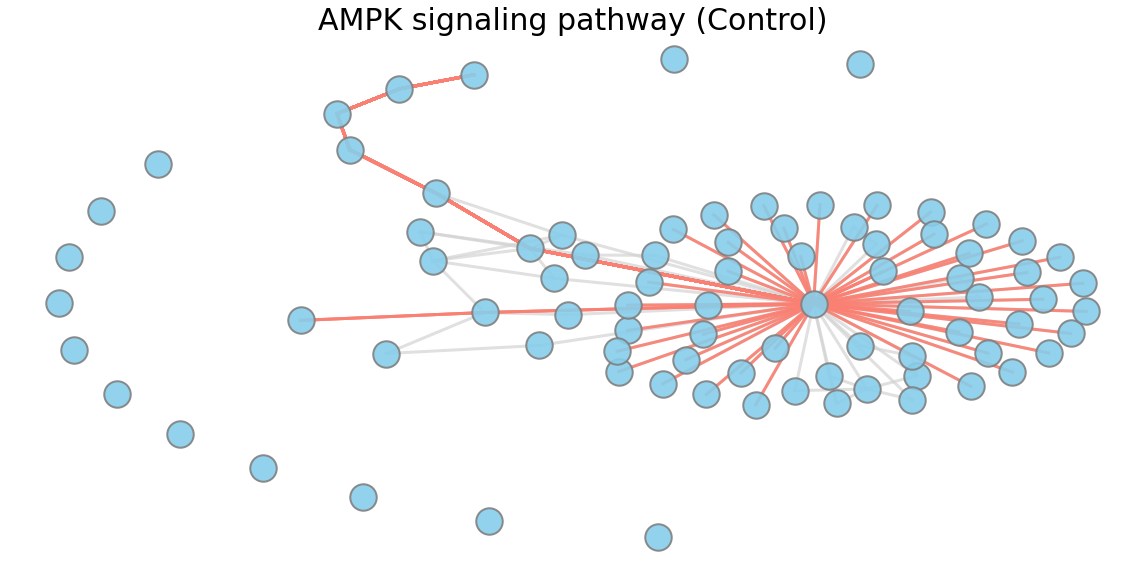

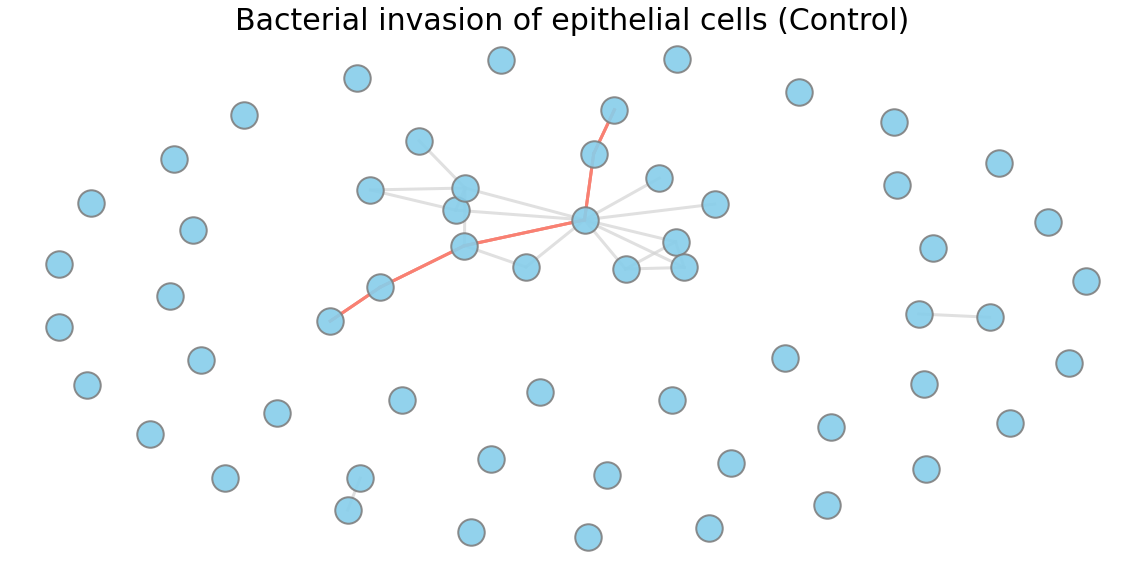

In [ ]:
import matplotlib.pyplot as plt
import math

random.seed(59)
np.random.seed(59)

# 1. Your list of human‐readable pathway names
test_pathways = [
    "AMPK signaling pathway",
    "Bacterial invasion of epithelial cells"]

# 2. Map those names to KEGG pathway IDs
pathway_to_kegg = { "AMPK signaling pathway": "hsa04152",
    "Bacterial invasion of epithelial cells": "hsa05100"
}

# ---------------- Helper Function: Leaf-to-Farthest Chain ----------------
def get_leaf_to_farthest_chains(graph, min_length=5):
    """
    For each leaf node (degree == 1) in the graph, find its farthest reachable
    leaf node (by shortest path distance). If that path has at least 'min_length'
    nodes, record that path (as a tuple of vertex indices). Duplicate paths are removed.
    Only candidates with finite distances are considered.
    
    Parameters:
        graph: an igraph.Graph object.
        min_length (int): minimum number of nodes that the chain must have.
    
    Returns:
        A list of unique paths (each is a tuple of vertex indices). If no valid path is found, returns an empty list.
    """
    # Identify leaf nodes (strictly degree == 1)
    leaves = [i for i, d in enumerate(graph.degree()) if d == 1]
    chains = []
    for leaf in leaves:
        distances = graph.shortest_paths(source=leaf)[0]
        max_dist = -1
        farthest_candidates = []
        for candidate in leaves:
            if candidate == leaf:
                continue
            # Skip if candidate is unreachable
            if distances[candidate] == float('inf') or math.isinf(distances[candidate]):
                continue
            if distances[candidate] > max_dist:
                max_dist = distances[candidate]
                farthest_candidates = [candidate]
            elif distances[candidate] == max_dist:
                farthest_candidates.append(candidate)
        # Record the chain if a candidate exists and meets the min_length condition
        if farthest_candidates and max_dist >= min_length:
            chosen = random.choice(farthest_candidates)
            path = graph.get_shortest_paths(leaf, to=chosen, output="vpath")[0]
            if len(path) >= min_length:
                chains.append(tuple(path))
    # Remove duplicate paths (order matters so reverse duplicates are removed)
    unique_chains = list(set(chains))
    return unique_chains

def draw_igraph(ax, graph, title="", 
                highlight_chain=True, chain_color="#FFC067", 
                min_chain_length=5,
                include_isolated=False):
    """
    Draws an igraph.Graph with an option to include or exclude
    nodes of degree zero (isolated nodes).

    Parameters:
      ax: matplotlib axis
      graph: igraph.Graph
      title: plot title
      highlight_chain: whether to highlight leaf‑to‑leaf chains
      chain_color: color for the highlighted chains
      min_chain_length: minimum chain length to highlight
      include_isolated: if True, plot nodes with degree==0; otherwise hide them
    """
    layout = graph.layout("fr")
    pos = {i: coord for i, coord in enumerate(layout.coords)}
    
    # draw all edges in light gray
    for edge in graph.es:
        u, v = edge.tuple
        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color="lightgray", linewidth=3, alpha=0.7, zorder=1
        )
    
    # highlight chains exactly as before, at zorder=1 so nodes (z=2) sit on top
    if highlight_chain:
        chains = get_leaf_to_farthest_chains(graph, min_length=min_chain_length)
        for chain in chains:
            for a, b in zip(chain, chain[1:]):
                ax.plot(
                    [pos[a][0], pos[b][0]],
                    [pos[a][1], pos[b][1]],
                    color=chain_color, linewidth=3, alpha=0.9, zorder=1
                )
    
    # choose which nodes to plot
    if include_isolated:
        nodes_to_plot = list(range(graph.vcount()))
    else:
        nodes_to_plot = [i for i in range(graph.vcount()) if graph.degree(i) > 0]
    
    xs = [pos[i][0] for i in nodes_to_plot]
    ys = [pos[i][1] for i in nodes_to_plot]
    
    ax.scatter(
        xs, ys,
        c="#87CEEB", s=700, alpha=0.9,
        edgecolors="gray", linewidths=2, zorder=2
    )
    
    ax.set_title(title, fontsize=30)
    ax.axis("off")

# 4. Loop, plot
for name in test_pathways:
    kegg_id = pathway_to_kegg.get(name)
    if kegg_id is None:
        print(f"⚠️ No KEGG ID for '{name}', skipping.")
        continue

    # fetch genes and build subgraph
    genes = utilities.get_genes_in_pathway(kegg_id)
    idxs = [v.index for v in G_s_ctrl.vs if v["name"] in genes]
    subg = G_s_ctrl.induced_subgraph(idxs)
    if subg.vcount() == 0:
        print(f"⚠️ Subgraph empty for '{name}', skipping.")
        continue

    # plot
    fig, ax = plt.subplots(figsize=(16, 8))
    draw_igraph(ax, subg,
                title=f"{name} (Control)",
                highlight_chain=True,
                chain_color="#FA8072",
                min_chain_length=5, include_isolated=True)
    plt.tight_layout()


    plt.show(fig)


# If we only want to highlight edges corresponding to chains of length >= 5

<ipython-input-2-7a63b20c5213>:36: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  distances = graph.shortest_paths(source=leaf)[0]


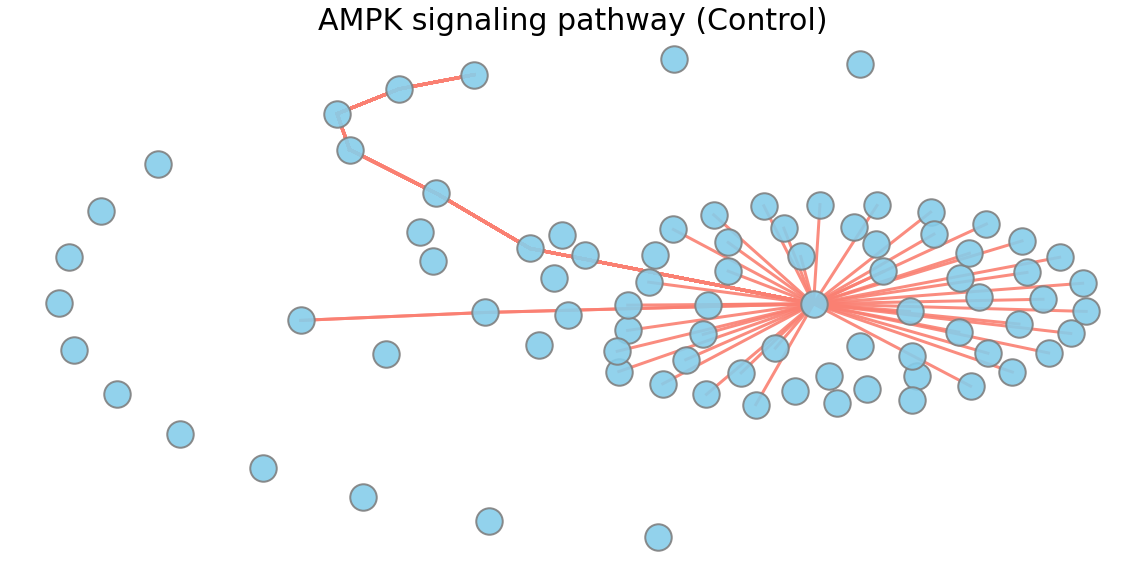

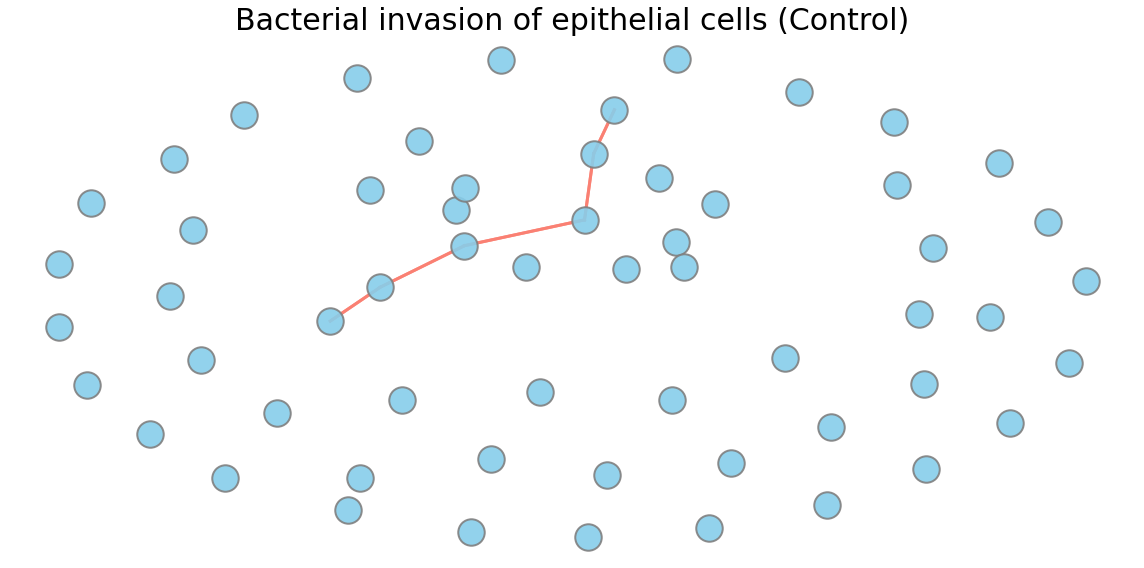

In [ ]:
random.seed(59)
np.random.seed(59)

def draw_igraph(ax, graph, title="", 
                highlight_chain=True, chain_color="#FFC067", 
                min_chain_length=5,
                include_isolated=False):
    """
    Draws an igraph.Graph, but only plots the red-highlighted chains—
    the default gray edges are no longer drawn.
    """
    layout = graph.layout("fr")
    pos = {i: coord for i, coord in enumerate(layout.coords)}
    
    # highlight chains only
    if highlight_chain:
        chains = get_leaf_to_farthest_chains(graph, min_length=min_chain_length)
        for chain in chains:
            for a, b in zip(chain, chain[1:]):
                ax.plot(
                    [pos[a][0], pos[b][0]],
                    [pos[a][1], pos[b][1]],
                    color=chain_color, linewidth=3, alpha=0.9, zorder=1
                )
    
    # choose which nodes to plot
    if include_isolated:
        nodes_to_plot = list(range(graph.vcount()))
    else:
        nodes_to_plot = [i for i in range(graph.vcount()) if graph.degree(i) > 0]
    
    xs = [pos[i][0] for i in nodes_to_plot]
    ys = [pos[i][1] for i in nodes_to_plot]
    
    ax.scatter(
        xs, ys,
        c="#87CEEB", s=700, alpha=0.9,
        edgecolors="gray", linewidths=2, zorder=2
    )
    
    ax.set_title(title, fontsize=30)
    ax.axis("off")
    

# 4. Loop, plot
for name in test_pathways:
    kegg_id = pathway_to_kegg.get(name)
    if kegg_id is None:
        print(f"⚠️ No KEGG ID for '{name}', skipping.")
        continue

    # fetch genes and build subgraph
    genes = utilities.get_genes_in_pathway(kegg_id)
    idxs = [v.index for v in G_s_ctrl.vs if v["name"] in genes]
    subg = G_s_ctrl.induced_subgraph(idxs)
    if subg.vcount() == 0:
        print(f"⚠️ Subgraph empty for '{name}', skipping.")
        continue

    # plot
    fig, ax = plt.subplots(figsize=(16, 8))
    draw_igraph(ax, subg,
                title=f"{name} (Control)",
                highlight_chain=True,
                chain_color="#FA8072",
                min_chain_length=5, include_isolated=True)
    plt.tight_layout()

    plt.show(fig)

